In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt

import gspread
import google.auth

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
credentials, project_id = google.auth.default()
gc = gspread.Client(auth=credentials)

In [ ]:
sheet_url = 'https://docs.google.com/spreadsheets/d/10-gFVKnAxfBb2dWujfYUFxUzvLdAZVE_y2gdvv2_iY4/edit#gid=0'
sheet = gc.open_by_url(sheet_url)
worksheet = sheet.sheet1
data = worksheet.get_all_records()

In [ ]:
apple_df = pd.DataFrame(data)

In [ ]:

apple_df.columns

Index(['date', 'target', 'text', 'clean_text', 'date_no_tz', 'clean_date',
       'Sentiment'],
      dtype='object')

In [ ]:
df = apple_df[['clean_text', 'Sentiment']].dropna().copy()

In [ ]:
df['Sentiment'] = df['Sentiment'].astype(str).str.strip().str.lower()


# ── Preprocessing branches ────────────────────────────────────
# LDA benefits from lemmatization; transformers perform better on natural surface forms
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(w) for w in text.split()])

df['lemmatized_text'] = df['clean_text'].apply(lemmatize_text)

In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
negative,8746
neutral,7000
positive,5523


In [ ]:
def fit_lda(texts, n_topics=6):
    vectorizer = CountVectorizer(
        stop_words="english",
        max_df=0.85,
        min_df=10,
        max_features=6000,
        ngram_range=(1, 2)
    )
    X = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch"
    )
    doc_topic = lda.fit_transform(X)

    return lda, vectorizer, doc_topic

In [ ]:
def print_topics(lda_model, vectorizer, n_top_words=12):
    feature_names = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(lda_model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_terms = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx + 1}: {', '.join(top_terms)}")

In [ ]:
# ── CELL: LDA topic number selection via held-out perplexity ──
from sklearn.model_selection import train_test_split

print("=" * 70)
print("LDA Topic Number Selection (held-out perplexity, lower = better)")
print("=" * 70)

cv_results = {}

for s in ['negative', 'neutral', 'positive']:
    texts = df.loc[df['Sentiment'] == s, 'lemmatized_text'].astype(str).tolist()

    # 80/20 split within each sentiment group
    train_texts, val_texts = train_test_split(
        texts, test_size=0.2, random_state=42
    )

    cv_results[s] = {}
    print(f"\n--- {s.upper()} ---")

    for n_topics in [4, 6, 8]:
        # Fit vectoriser on training, transform both
        vectorizer = CountVectorizer(
            stop_words='english', max_df=0.85, min_df=10,
            max_features=6000, ngram_range=(1, 2)
        )
        X_train = vectorizer.fit_transform(train_texts)
        X_val = vectorizer.transform(val_texts)

        # Fit LDA on training
        lda = LatentDirichletAllocation(
            n_components=n_topics, random_state=42,
            learning_method='batch', max_iter=20
        )
        lda.fit(X_train)

        # Evaluate perplexity on validation
        perplexity = lda.perplexity(X_val)
        cv_results[s][n_topics] = perplexity
        print(f"  n_topics = {n_topics}: perplexity = {perplexity:.2f}")

    best_n = min(cv_results[s], key=cv_results[s].get)
    print(f"  → Best: n_topics = {best_n}")

# Summary table
print("\n" + "=" * 70)
print("Summary: Held-out Perplexity by Topic Number")
print("=" * 70)
print(f"{'Sentiment':<12} {'n=4':>10} {'n=6':>10} {'n=8':>10}")
for s, scores in cv_results.items():
    print(f"{s:<12} {scores[4]:>10.2f} {scores[6]:>10.2f} {scores[8]:>10.2f}")

LDA Topic Number Selection (held-out perplexity, lower = better)

--- NEGATIVE ---
  n_topics = 4: perplexity = 819.94
  n_topics = 6: perplexity = 972.11
  n_topics = 8: perplexity = 1079.60
  → Best: n_topics = 4

--- NEUTRAL ---
  n_topics = 4: perplexity = 595.51
  n_topics = 6: perplexity = 699.71
  n_topics = 8: perplexity = 812.29
  → Best: n_topics = 4

--- POSITIVE ---
  n_topics = 4: perplexity = 576.12
  n_topics = 6: perplexity = 705.18
  n_topics = 8: perplexity = 821.41
  → Best: n_topics = 4

Summary: Held-out Perplexity by Topic Number
Sentiment           n=4        n=6        n=8
negative         819.94     972.11    1079.60
neutral          595.51     699.71     812.29
positive         576.12     705.18     821.41


In [ ]:
# ── CELL: Compare LDA outputs at n=4 vs n=6 ─────────────────
print("=" * 75)
print("LDA Topic Comparison: n_topics = 4 vs n_topics = 6")
print("=" * 75)

for s in ['negative', 'neutral', 'positive']:
    texts = df.loc[df['Sentiment'] == s, 'lemmatized_text'].astype(str)

    print(f"\n{'─' * 75}")
    print(f"  {s.upper()}")
    print(f"{'─' * 75}")

    # n_topics = 4
    lda4, vec4, _ = fit_lda(texts, n_topics=4)
    print(f"\n  ── n_topics = 4 ──")
    print_topics(lda4, vec4, n_top_words=10)

    # n_topics = 6
    lda6, vec6, _ = fit_lda(texts, n_topics=6)
    print(f"\n  ── n_topics = 6 ──")
    print_topics(lda6, vec6, n_top_words=10)

LDA Topic Comparison: n_topics = 4 vs n_topics = 6

───────────────────────────────────────────────────────────────────────────
  NEGATIVE
───────────────────────────────────────────────────────────────────────────

  ── n_topics = 4 ──
Topic 1: ipod, mac, just, itunes, im, dont, think, iphone, wont, sad
Topic 2: macbook, just, store, apple, mac, got, machine, ha, pro, apple store
Topic 3: ipod, im, machine, iphone, new, like, going, wa, touch, need
Topic 4: iphone, 30, update, work, new, doesnt, iphone 30, phone, 3gs, want

  ── n_topics = 6 ──
Topic 1: mac, ipod, just, dont, think, iphone, wont, im, know, want
Topic 2: macbook, just, apple, store, got, bad, pro, machine, apple store, im
Topic 3: ipod, machine, im, iphone, need, wa, broke, going, new, day
Topic 4: iphone, doesnt, work, 30, phone, 3g, iphone 30, app, safari, want
Topic 5: itunes, iphone, update, working, 30, feel, isnt, download, im, software
Topic 6: iphone, ipod, new, touch, 3gs, new iphone, ipod touch, wait, im, wa


In [ ]:
models = {}

for s in ['negative', 'neutral', 'positive']:
    texts = df.loc[df['Sentiment'] == s, 'lemmatized_text'].astype(str)
    lda, vec, doc_topic = fit_lda(texts, n_topics=6)

    models[s] = {"lda": lda, "vec": vec, "doc_topic": doc_topic}

    print(f"\n===== {s.upper()} TOPICS =====")
    print_topics(lda, vec, n_top_words=12)


===== NEGATIVE TOPICS =====
Topic 1: mac, ipod, just, dont, think, iphone, wont, im, know, want, ive, lost
Topic 2: macbook, just, apple, store, got, bad, pro, machine, apple store, im, ha, macbook pro
Topic 3: ipod, machine, im, iphone, need, wa, broke, going, new, day, today, like
Topic 4: iphone, doesnt, work, 30, phone, 3g, iphone 30, app, safari, want, dont, tweetdeck
Topic 5: itunes, iphone, update, working, 30, feel, isnt, download, im, software, iphone 30, just
Topic 6: iphone, ipod, new, touch, 3gs, new iphone, ipod touch, wait, im, wa, iphone 3gs, wont

===== NEUTRAL TOPICS =====
Topic 1: iphone, update, 30, mac, waiting, iphone 30, work, like, just, look, working, leopard
Topic 2: machine, iphone, time, need, app, wish, like, wa, wwdc, store, app store, make
Topic 3: iphone, itunes, im, 3gs, just, ipod, wa, 3g, music, phone, iphone 3gs, iphone 3g
Topic 4: iphone, new, apple, want, new iphone, macbook, store, apple store, song, ipod, buy, squarespace
Topic 5: mac, iphone, im

In [ ]:
print("LDA topic sizes (n=6) per sentiment group:\n")
for s in ['negative', 'neutral', 'positive']:
    counts = np.bincount(models[s]['doc_topic'].argmax(axis=1))
    print(f"{s.upper()}:")
    for i, c in enumerate(counts):
        print(f"  Topic {i+1}: {c} tweets")
    print(f"  Smallest: {counts.min()}, Largest: {counts.max()}\n")

LDA topic sizes (n=6) per sentiment group:

NEGATIVE:
  Topic 1: 1825 tweets
  Topic 2: 1064 tweets
  Topic 3: 1717 tweets
  Topic 4: 1727 tweets
  Topic 5: 1145 tweets
  Topic 6: 1268 tweets
  Smallest: 1064, Largest: 1825

NEUTRAL:
  Topic 1: 907 tweets
  Topic 2: 983 tweets
  Topic 3: 1455 tweets
  Topic 4: 1146 tweets
  Topic 5: 1297 tweets
  Topic 6: 1212 tweets
  Smallest: 907, Largest: 1455

POSITIVE:
  Topic 1: 828 tweets
  Topic 2: 997 tweets
  Topic 3: 1098 tweets
  Topic 4: 1044 tweets
  Topic 5: 688 tweets
  Topic 6: 868 tweets
  Smallest: 688, Largest: 1098



In [ ]:
def plot_top_words(lda_model, vectorizer, topic_idx, n_top_words=10):
    feature_names = vectorizer.get_feature_names_out()
    topic = lda_model.components_[topic_idx]
    top_indices = topic.argsort()[::-1][:n_top_words]

    words = [feature_names[i] for i in top_indices]
    weights = topic[top_indices]

    plt.figure()
    plt.barh(words[::-1], weights[::-1])
    plt.title(f"Topic {topic_idx + 1} – Top Words")
    plt.xlabel("Word Weight")
    plt.tight_layout()
    plt.show()

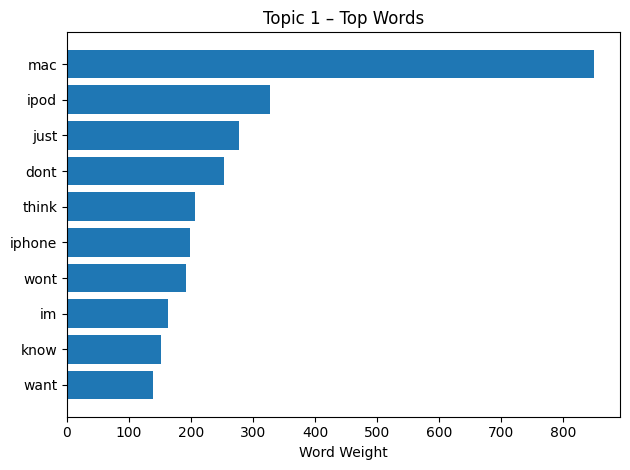

In [ ]:
plot_top_words(models['negative']['lda'], models['negative']['vec'], topic_idx=0)

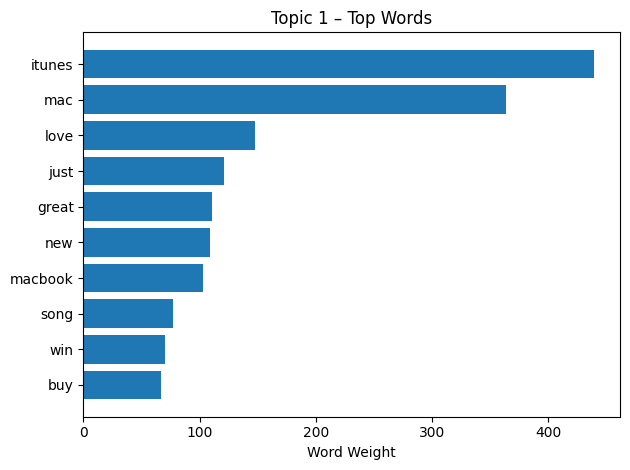

In [ ]:
plot_top_words(models['positive']['lda'], models['positive']['vec'], topic_idx=0)

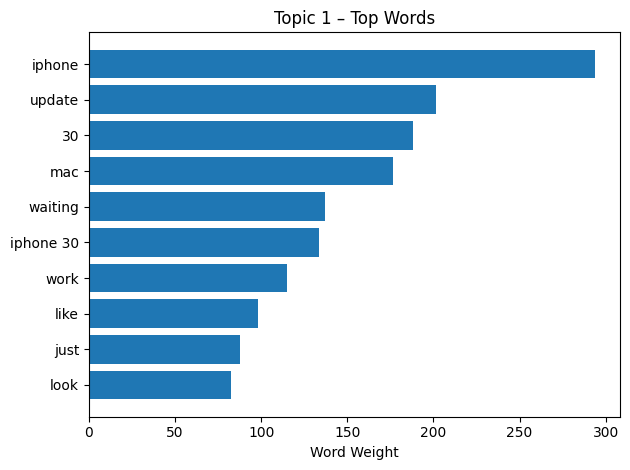

In [ ]:
plot_top_words(models['neutral']['lda'], models['neutral']['vec'], topic_idx=0)

In [ ]:
def plot_topic_distribution(doc_topic, sentiment_label):
    topic_counts = np.bincount(doc_topic.argmax(axis=1))

    plt.figure()
    plt.bar(range(len(topic_counts)), topic_counts)
    plt.xlabel("Topic")
    plt.ylabel("Number of Tweets")
    plt.title(f"Topic Distribution – {sentiment_label.capitalize()} Sentiment")
    plt.tight_layout()
    plt.show()

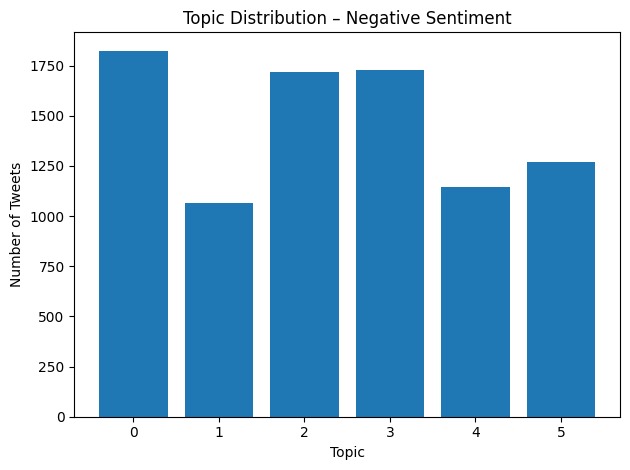

In [ ]:
plot_topic_distribution(models['negative']['doc_topic'], "negative")

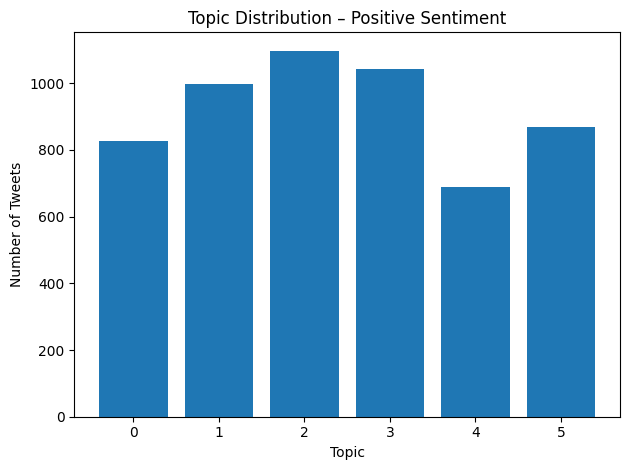

In [ ]:
plot_topic_distribution(models['positive']['doc_topic'], "positive")

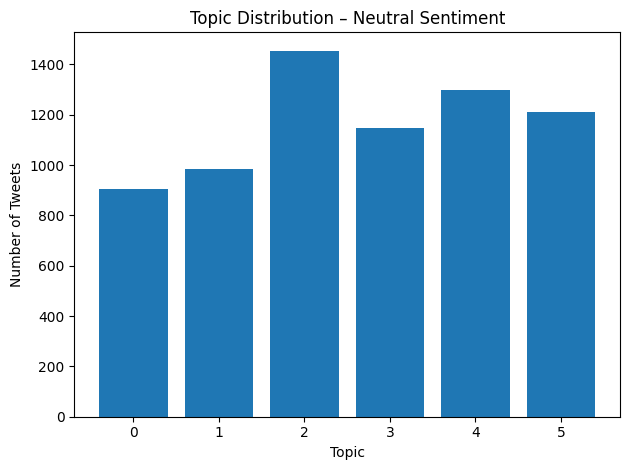

In [ ]:
plot_topic_distribution(models['neutral']['doc_topic'], "neutral")

In [ ]:
def plot_topic_heatmap(doc_topic, n_docs=50):
    subset = doc_topic[:n_docs]
    plt.figure()
    plt.imshow(subset, aspect='auto')
    plt.colorbar(label="Topic Probability")
    plt.xlabel("Topic")
    plt.ylabel("Document")
    plt.title("Document–Topic Distribution (Sample)")
    plt.show()

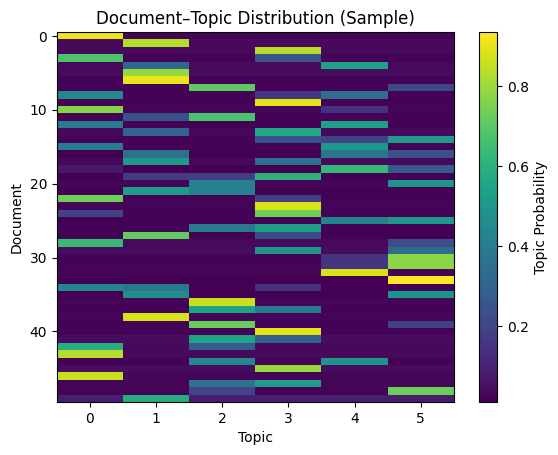

In [ ]:
plot_topic_heatmap(models['negative']['doc_topic'])

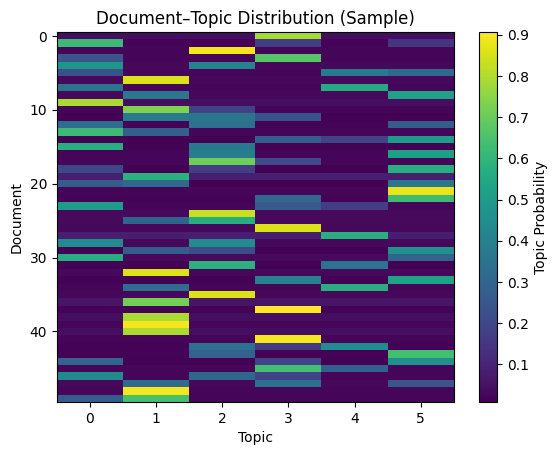

In [ ]:
plot_topic_heatmap(models['positive']['doc_topic'])

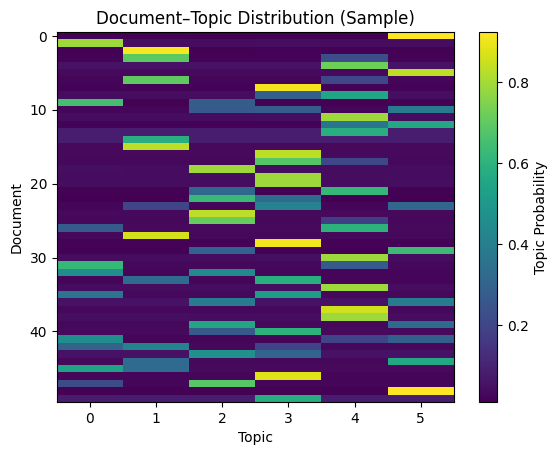

In [ ]:
plot_topic_heatmap(models['neutral']['doc_topic'])

## **BERTopic**

In [ ]:
# ── CELL: Install & imports ───────────────────────────────────
!pip install bertopic

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer as BertCountVectorizer
import plotly.io as pio
pio.renderers.default = "colab"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.4 MB/s eta 0:00:00


In [ ]:
# ── CELL: Shared BERTopic components ─────────────────────────
# We define the sub-models once and reuse across all three sentiment groups.
# This keeps the comparison fair — same architecture, different data.

embedding_model = SentenceTransformer("all-mpnet-base-v2")

def make_umap():
    return UMAP(
        n_neighbors=10,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

def make_hdbscan():
    return HDBSCAN(
        min_cluster_size=100,   # each sentiment group has 5000-8000 tweets
        min_samples=30,        # increase if you get too many topics
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )

def make_vectorizer():
    return BertCountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5
    )

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.7 MB/s eta 0:00:00


In [ ]:
# ── CELL: BERTopic min_cluster_size selection via topic coherence ──
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

print("=" * 70)
print("BERTopic min_cluster_size Selection (c_v coherence, higher = better)")
print("=" * 70)

bertopic_cv = {}

for sentiment in ['negative', 'neutral', 'positive']:
    texts = df.loc[df['Sentiment'] == sentiment, 'clean_text'].astype(str).tolist()

    # Tokenise for coherence calculation
    tokenised = [t.split() for t in texts]
    dictionary = Dictionary(tokenised)

    bertopic_cv[sentiment] = {}
    print(f"\n--- {sentiment.upper()} ---")

    for mcs in [50, 100, 150]:
        try:
            model = BERTopic(
                embedding_model=embedding_model,
                umap_model=make_umap(),
                hdbscan_model=HDBSCAN(
                    min_cluster_size=mcs, min_samples=30,
                    metric="euclidean", cluster_selection_method="eom",
                    prediction_data=True
                ),
                vectorizer_model=make_vectorizer(),
                top_n_words=10, verbose=False
            )
            topics, _ = model.fit_transform(texts)

            # Get topic words (excluding noise topic -1)
            topic_words = []
            for tid in sorted(set(topics)):
                if tid == -1:
                    continue
                words = [w for w, _ in model.get_topic(tid)][:10]
                topic_words.append(words)

            if len(topic_words) < 2:
                print(f"  min_cluster_size = {mcs}: too few topics "
                      f"({len(topic_words)}), skipping")
                continue

            # Compute c_v coherence
            cm = CoherenceModel(
                topics=topic_words, texts=tokenised,
                dictionary=dictionary, coherence='c_v'
            )
            coherence = cm.get_coherence()
            n_topics = len(topic_words)
            n_noise = topics.count(-1)

            bertopic_cv[sentiment][mcs] = {
                'coherence': coherence,
                'n_topics': n_topics,
                'n_noise': n_noise
            }
            print(f"  min_cluster_size = {mcs}: coherence = {coherence:.3f} | "
                  f"topics = {n_topics} | noise = {n_noise}")

        except ValueError as e:
            print(f"  min_cluster_size = {mcs}: failed ({e}), skipping")
            continue
        except Exception as e:
            print(f"  min_cluster_size = {mcs}: failed ({type(e).__name__}: {e}), skipping")
            continue

    if bertopic_cv[sentiment]:
        best_mcs = max(bertopic_cv[sentiment],
                       key=lambda k: bertopic_cv[sentiment][k]['coherence'])
        print(f"  → Best: min_cluster_size = {best_mcs}")

BERTopic min_cluster_size Selection (c_v coherence, higher = better)

--- NEGATIVE ---
  min_cluster_size = 50: coherence = 0.425 | topics = 32 | noise = 2666
  min_cluster_size = 100: coherence = 0.366 | topics = 8 | noise = 535
  min_cluster_size = 150: coherence = 0.312 | topics = 5 | noise = 15
  → Best: min_cluster_size = 50

--- NEUTRAL ---
  min_cluster_size = 50: coherence = 0.417 | topics = 22 | noise = 2414
  min_cluster_size = 100: coherence = 0.423 | topics = 8 | noise = 1100
  min_cluster_size = 150: failed (max_df corresponds to < documents than min_df), skipping
  → Best: min_cluster_size = 100

--- POSITIVE ---
  min_cluster_size = 50: coherence = 0.381 | topics = 12 | noise = 998
  min_cluster_size = 100: coherence = 0.325 | topics = 4 | noise = 207
  min_cluster_size = 150: coherence = 0.307 | topics = 4 | noise = 194
  → Best: min_cluster_size = 50


In [ ]:
# ── CELL: Compare BERTopic outputs at min_cluster_size = 50 vs 100 ──
print("=" * 75)
print("BERTopic Topic Comparison: min_cluster_size = 50 vs 100")
print("=" * 75)

for sentiment in ['negative', 'neutral', 'positive']:
    texts = df.loc[df['Sentiment'] == sentiment, 'clean_text'].astype(str).tolist()

    print(f"\n{'─' * 75}")
    print(f"  {sentiment.upper()}  ({len(texts)} tweets)")
    print(f"{'─' * 75}")

    for mcs in [50, 100]:
        try:
            model = BERTopic(
                embedding_model=embedding_model,
                umap_model=make_umap(),
                hdbscan_model=HDBSCAN(
                    min_cluster_size=mcs, min_samples=30,
                    metric="euclidean", cluster_selection_method="eom",
                    prediction_data=True
                ),
                vectorizer_model=make_vectorizer(),
                top_n_words=10, verbose=False
            )
            topics, _ = model.fit_transform(texts)

            n_topics = len(set(topics)) - (1 if -1 in topics else 0)
            n_noise = topics.count(-1)

            print(f"\n  ── min_cluster_size = {mcs} | "
                  f"topics = {n_topics} | noise = {n_noise} "
                  f"({n_noise/len(texts)*100:.1f}%) ──")

            for tid in sorted(set(topics)):
                if tid == -1:
                    continue
                words = [w for w, _ in model.get_topic(tid)][:8]
                topic_size = topics.count(tid)
                print(f"  Topic {tid+1:>2} (n={topic_size:>4}): {', '.join(words)}")

        except Exception as e:
            print(f"\n  ── min_cluster_size = {mcs}: failed ({e}) ──")

BERTopic Topic Comparison: min_cluster_size = 50 vs 100

───────────────────────────────────────────────────────────────────────────
  NEGATIVE  (8746 tweets)
───────────────────────────────────────────────────────────────────────────

  ── min_cluster_size = 50 | topics = 32 | noise = 2666 (30.5%) ──
  Topic  1 (n=1330): ipod, ipod touch, touch, dead, im, lost, music, ipods
  Topic  2 (n= 580): itunes, songs, music, podcasts, download, itunes store, library, deleted
  Topic  3 (n= 420): twitter, tweetie, tweet, iphone, app, tweeting, crashes, crashing
  Topic  4 (n= 418): mac, macbook, macs, pc, dont, want, windows, im
  Topic  5 (n= 290): stomache, hurts, bad, worst, sick, feel, woke, im
  Topic  6 (n= 289): 3gs, 3g, iphone 3gs, iphone 3g, upgrade, new iphone, iphone, new
  Topic  7 (n= 274): screen, iphone, cracked, dropped, broke iphone, broke, broken, phone
  Topic  8 (n= 263): macbook, pro, macbook pro, mac, drive, hard, screen, imac
  Topic  9 (n= 226): iphone, blackberry, want,

In [ ]:
# ── CELL: Fit BERTopic per sentiment ─────────────────────────
# Mirrors your LDA loop in Cell 12 exactly.
# Results stored in bert_models dict, same pattern as your `models` dict.

bert_models = {}

for sentiment in ['negative', 'neutral', 'positive']:
    texts = df.loc[df['Sentiment'] == sentiment, 'clean_text'].astype(str).tolist()
    print(f"\n{'='*55}")
    print(f"  BERTopic – {sentiment.upper()}  ({len(texts)} tweets)")
    print(f"{'='*55}")

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=make_umap(),
        hdbscan_model=make_hdbscan(),
        vectorizer_model=make_vectorizer(),
        top_n_words=12,
        verbose=False          # set True if you want progress logs
    )

    topics, probs = topic_model.fit_transform(texts)

    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    n_noise  = topics.count(-1)
    print(f"Topics found: {n_topics}  |  Noise tweets (topic -1): {n_noise}")

    # Print top words per topic (same format as your print_topics function)
    for tid in sorted(set(topics)):
        if tid == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(tid)]
        print(f"  Topic {tid + 1:>2}: {', '.join(words)}")

    bert_models[sentiment] = {
        "model":  topic_model,
        "topics": topics,
        "probs":  probs,
        "texts":  texts
    }


  BERTopic – NEGATIVE  (8746 tweets)
Topics found: 8  |  Noise tweets (topic -1): 535
  Topic  1: iphone, 30, update, new, new iphone, apple, im, phone, just, work, dont, os
  Topic  2: ipod, itunes, im, just, songs, touch, ipod touch, lost, new, got, dead, dont
  Topic  3: mac, macbook, pro, macbook pro, just, im, imac, pc, work, dont, new, want
  Topic  4: twitter, iphone, tweetie, tweet, app, tweeting, just, doesnt, mac, crashes, crashing, like
  Topic  5: machine, washing, washing machine, coffee, machines, broken, just, broke, work, day, water, money
  Topic  6: stomache, hurts, bad, im, sick, feel, worst, woke, like, got, ate, feeling
  Topic  7: safari, google, mac, beta, open, doesnt, crashes, work, crash, page, dont, ive
  Topic  8: smack, smacked, face, smacks, just, head, got, im, sore, ass, shit, want

  BERTopic – NEUTRAL  (7000 tweets)
Topics found: 4  |  Noise tweets (topic -1): 46
  Topic  1: iphone, new, got, need, work, like, want, time, going, today, know, use
  Top

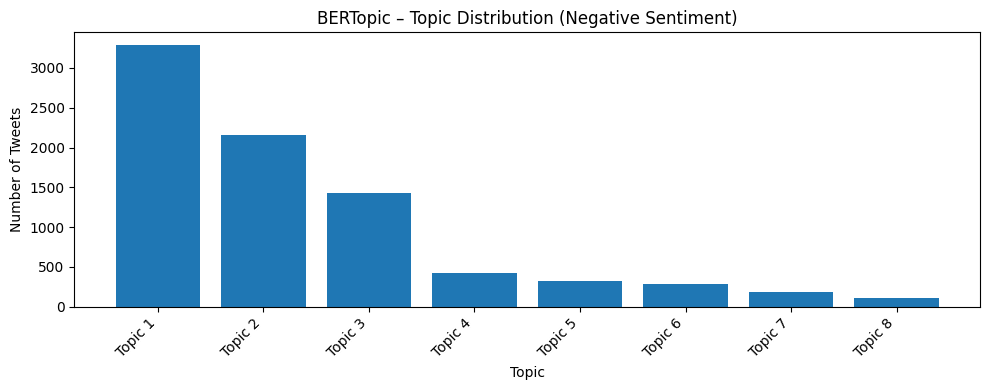

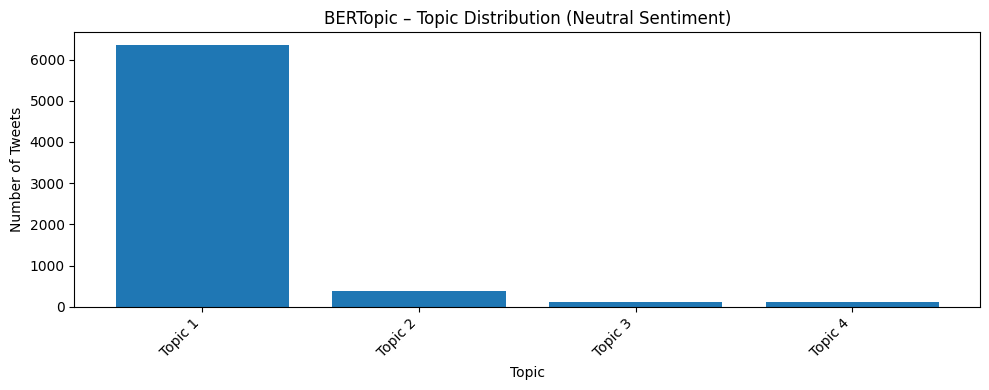

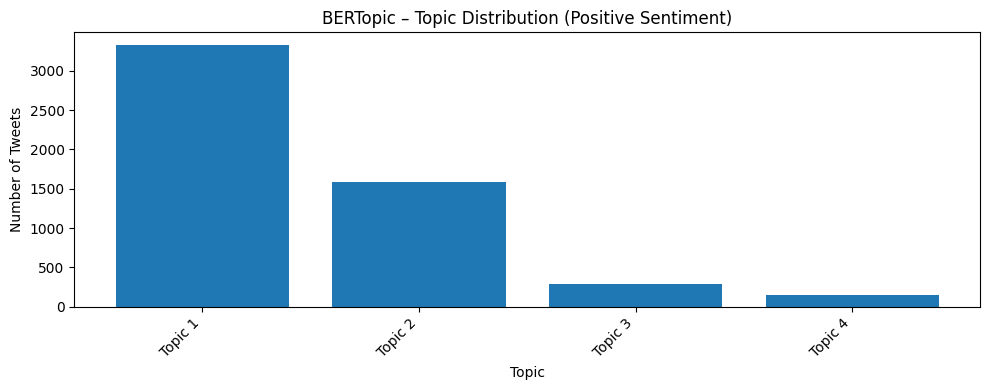

In [ ]:
# ── CELL: Topic distribution bar chart per sentiment ─────────
# Mirrors your plot_topic_distribution function from Cell 17.

for sentiment in ['negative', 'neutral', 'positive']:
    topics = bert_models[sentiment]['topics']

    # Exclude noise (-1) from the distribution plot
    filtered = [t for t in topics if t != -1]
    topic_counts = pd.Series(filtered).value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    plt.bar(
        [f"Topic {t+1}" for t in topic_counts.index],
        topic_counts.values
    )
    plt.title(f"BERTopic – Topic Distribution ({sentiment.capitalize()} Sentiment)")
    plt.xlabel("Topic")
    plt.ylabel("Number of Tweets")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── CELL: BERTopic barchart visualisation per sentiment ──────
# Interactive Plotly version — richer than the matplotlib bar above.

for sentiment in ['negative', 'neutral', 'positive']:
    model = bert_models[sentiment]['model']
    print(f"\n{sentiment.upper()} – Top Words per BERTopic Topic")
    fig = model.visualize_barchart(top_n_topics=6, n_words=10)
    fig.show()


NEGATIVE – Top Words per BERTopic Topic



NEUTRAL – Top Words per BERTopic Topic



POSITIVE – Top Words per BERTopic Topic


In [ ]:
# ── CELL: LDA vs BERTopic topic comparison ───────────────────
# Side-by-side printout so you can directly compare what each model found.

print("=" * 65)
print("LDA  vs  BERTopic  –  Top Words Comparison")
print("=" * 65)

feature_names_cache = {s: models[s]['vec'].get_feature_names_out()
                       for s in ['negative', 'neutral', 'positive']}

for sentiment in ['negative', 'neutral', 'positive']:
    print(f"\n── {sentiment.upper()} ──")

    # LDA topics
    lda_model = models[sentiment]['lda']
    vec       = models[sentiment]['vec']
    feat      = feature_names_cache[sentiment]
    print("  LDA:")
    for idx, topic in enumerate(lda_model.components_):
        top_words = [feat[i] for i in topic.argsort()[::-1][:8]]
        print(f"    Topic {idx+1}: {', '.join(top_words)}")

    # BERTopic topics
    bert_model = bert_models[sentiment]['model']
    print("  BERTopic:")
    topic_info = bert_model.get_topic_info()
    for _, row in topic_info.iterrows():
        if row['Topic'] == -1:
            continue
        words = [w for w, _ in bert_model.get_topic(row['Topic'])][:8]
        print(f"    Topic {row['Topic']+1}: {', '.join(words)}")

LDA  vs  BERTopic  –  Top Words Comparison

── NEGATIVE ──
  LDA:
    Topic 1: mac, ipod, just, dont, think, iphone, wont, im
    Topic 2: macbook, just, apple, store, got, bad, pro, machine
    Topic 3: ipod, machine, im, iphone, need, wa, broke, going
    Topic 4: iphone, doesnt, work, 30, phone, 3g, iphone 30, app
    Topic 5: itunes, iphone, update, working, 30, feel, isnt, download
    Topic 6: iphone, ipod, new, touch, 3gs, new iphone, ipod touch, wait
  BERTopic:
    Topic 1: iphone, 30, update, new, new iphone, apple, im, phone
    Topic 2: ipod, itunes, im, just, songs, touch, ipod touch, lost
    Topic 3: mac, macbook, pro, macbook pro, just, im, imac, pc
    Topic 4: twitter, iphone, tweetie, tweet, app, tweeting, just, doesnt
    Topic 5: machine, washing, washing machine, coffee, machines, broken, just, broke
    Topic 6: stomache, hurts, bad, im, sick, feel, worst, woke
    Topic 7: safari, google, mac, beta, open, doesnt, crashes, work
    Topic 8: smack, smacked, face, 

In [ ]:
# ── CELL: Noise summary ───────────────────────────────────────
# How many tweets per sentiment group were unclassifiable by BERTopic?

print("\nNoise tweet summary (topic -1 = unclustered by HDBSCAN):\n")
for sentiment in ['negative', 'neutral', 'positive']:
    topics    = bert_models[sentiment]['topics']
    total     = len(topics)
    n_noise   = topics.count(-1)
    pct_noise = n_noise / total * 100
    print(f"  {sentiment.capitalize():>10}: {n_noise:>4} / {total} tweets unclustered "
          f"({pct_noise:.1f}%)")


Noise tweet summary (topic -1 = unclustered by HDBSCAN):

    Negative:  535 / 8746 tweets unclustered (6.1%)
     Neutral:   46 / 7000 tweets unclustered (0.7%)
    Positive:  180 / 5523 tweets unclustered (3.3%)
